# AI-Powered Flood Risk Prediction
# Random Forest
## Ghale

Trains a Random Forest on Murray Bridge river level and rainfall, and compares it with Logistic Regression using F1 and MCC.

In [1]:
!pip install pandas numpy scikit-learn joblib matplotlib -q


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\kingn\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Load and merge data

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, matthews_corrcoef, precision_score, recall_score, classification_report
import joblib

HERE = Path.cwd()
REPO = HERE if (HERE / "data").exists() else HERE.parent
DATA = REPO / "data"
MODELS = REPO / "models"

river = pd.read_csv(DATA / "murray_bridge_river_level_historical.csv", skiprows=4,
                    names=["datetime", "water_level_m", "conductivity", "water_temp_c"])
river["datetime"] = pd.to_datetime(river["datetime"], format="%H:%M:%S %d/%m/%Y", errors="coerce")
river = river.dropna(subset=["datetime", "water_level_m"]).sort_values("datetime").reset_index(drop=True)
river["date"] = river["datetime"].dt.normalize()

rain = pd.read_csv(DATA / "murray_bridge_daily_rainfall_full.csv")
rain["date"] = pd.to_datetime(dict(year=rain["Year"], month=rain["Month"], day=rain["Day"]), errors="coerce")
rain = rain[["date", "Rainfall amount (millimetres)"]].rename(columns={"Rainfall amount (millimetres)": "rain_mm"})

df = river.merge(rain, on="date", how="left")
df["rain_mm"] = df["rain_mm"].fillna(0.0)

print("Rows:", len(df))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
df[["date", "water_level_m", "rain_mm"]].tail()

Rows: 6364
Date range: 2009-01-08 to 2026-07-02


,date,water_level_m,rain_mm
6359,2026-06-28,0.668,0.0
6360,2026-06-29,0.648,0.3
6361,2026-06-30,0.686,1.4
6362,2026-07-01,0.694,0.5
6363,2026-07-02,0.730,10.6


## 2. Feature engineering

In [3]:
df["level_lag1"] = df["water_level_m"].shift(1)
df["level_lag2"] = df["water_level_m"].shift(2)
df["level_roll7"] = df["water_level_m"].shift(1).rolling(7).mean()
df["level_change3"] = df["water_level_m"].shift(1) - df["water_level_m"].shift(4)

df["rain_lag1"] = df["rain_mm"].shift(1)
df["rain_roll3"] = df["rain_mm"].shift(1).rolling(3).sum()
df["rain_roll7"] = df["rain_mm"].shift(1).rolling(7).sum()
df["rain_roll14"] = df["rain_mm"].shift(1).rolling(14).sum()
df["rain_roll30"] = df["rain_mm"].shift(1).rolling(30).sum()

features = ["level_lag1", "level_lag2", "level_roll7", "level_change3",
            "rain_lag1", "rain_roll3", "rain_roll7", "rain_roll14", "rain_roll30"]

df = df.dropna(subset=features)
threshold = df["water_level_m"].quantile(0.80)
df["high_risk"] = (df["water_level_m"] >= threshold).astype(int)

print("Risk threshold (m):", round(threshold, 3))
df["high_risk"].value_counts()

Risk threshold (m): 0.806


high_risk
0    5060
1    1274
Name: count, dtype: int64

## 3. Train/test split

In [4]:
X = df[features]
y = df["high_risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Train models

In [5]:
model_lr = LogisticRegression(class_weight="balanced", max_iter=2000)
model_lr.fit(X_train, y_train)

model_rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

print(classification_report(y_test, model_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1012
           1       0.85      0.77      0.81       255

    accuracy                           0.93      1267
   macro avg       0.90      0.87      0.88      1267
weighted avg       0.92      0.93      0.93      1267



## 5. Evaluate with F1 and MCC

In [6]:
def metrics_at(model, thr=0.50):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= thr).astype(int)
    return {
        "F1": round(f1_score(y_test, pred), 3),
        "MCC": round(matthews_corrcoef(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "precision": round(precision_score(y_test, pred), 3),
    }


default_table = pd.DataFrame({"Logistic Regression": metrics_at(model_lr), "Random Forest": metrics_at(model_rf)}).T
print(default_table.to_string())

                        F1    MCC  recall  precision
Logistic Regression  0.778  0.730   0.949      0.659
Random Forest        0.811  0.768   0.776      0.850


## 6. Tune the decision threshold

In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def best_f1_threshold(model):
    oof = cross_val_predict(model, X_train, y_train, cv=skf, method="predict_proba")[:, 1]
    grid = np.linspace(0.05, 0.95, 181)
    scores = [f1_score(y_train, (oof >= t).astype(int)) for t in grid]
    return float(grid[int(np.argmax(scores))])


t_lr = best_f1_threshold(model_lr)
t_rf = best_f1_threshold(model_rf)
print("Thresholds: LR =", round(t_lr, 3), " RF =", round(t_rf, 3))

tuned_table = pd.DataFrame({"Logistic Regression": metrics_at(model_lr, t_lr), "Random Forest": metrics_at(model_rf, t_rf)}).T
print(tuned_table.to_string())

Thresholds: LR = 0.725  RF = 0.425
                        F1    MCC  recall  precision
Logistic Regression  0.813  0.766   0.808      0.817
Random Forest        0.822  0.778   0.816      0.829


## 7. Feature importance

rain_lag1        0.022
rain_roll3       0.022
rain_roll7       0.027
rain_roll14      0.033
rain_roll30      0.035
level_change3    0.046
level_lag2       0.178
level_roll7      0.281
level_lag1       0.356


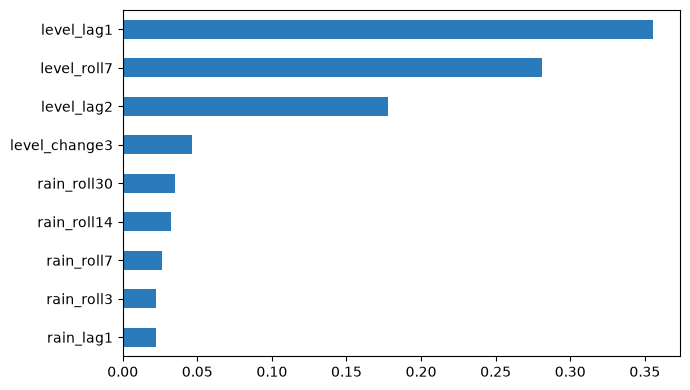

In [8]:
import matplotlib.pyplot as plt

importance = pd.Series(model_rf.feature_importances_, index=features).sort_values()
print(importance.round(3).to_string())
importance.plot(kind="barh", figsize=(7, 4), color="#2b7bba")
plt.tight_layout()
plt.show()

## 8. Save model

In [9]:
MODELS.mkdir(exist_ok=True)
bundle_rf = {"model": model_rf, "features": features, "threshold": round(t_rf, 3), "algorithm": "RandomForestClassifier"}
joblib.dump(bundle_rf, MODELS / "Random_Forest.joblib")
print("Saved models/Random_Forest.joblib (Random Forest,", len(features), "features)")

Saved models/Random_Forest.joblib (Random Forest, 9 features)
